# Trading con Opciones II — SPY vencimiento 2026-04-17
### Precios mid reales obtenidos dinámicamente con yfinance

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def payoff_estrategia(S_range, legs):
    """Calcula el P&L neto de una estrategia con cualquier número de legs."""
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
    return total

def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8, linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red', label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
TICKER      = "SPY"
EXPIRY      = "2026-04-17"   # vencimiento solicitado

spy = yf.Ticker(TICKER)

# Precio spot actual
S0 = spy.fast_info["last_price"]
print(f"Precio actual de {TICKER}: ${S0:.2f}")

# Cadena de opciones para el vencimiento indicado
opt = spy.option_chain(EXPIRY)
calls = opt.calls.copy()
puts  = opt.puts.copy()

# Calcular precio mid = (bid + ask) / 2
calls["mid"] = (calls["bid"] + calls["ask"]) / 2
puts["mid"]  = (puts["bid"]  + puts["ask"])  / 2

# Función auxiliar: obtener prima mid para un strike dado
def get_call_mid(K, df=calls):
    row = df[df["strike"] == K]
    if row.empty:
        raise ValueError(f"No hay call con strike {K} en la cadena para {EXPIRY}")
    return float(row["mid"].values[0])

def get_put_mid(K, df=puts):
    row = df[df["strike"] == K]
    if row.empty:
        raise ValueError(f"No hay put con strike {K} en la cadena para {EXPIRY}")
    return float(row["mid"].values[0])

print(f"\nStrikes disponibles (calls): {sorted(calls['strike'].tolist())[:20]} ...")
print(f"Vencimiento: {EXPIRY}")

Precio actual de SPY: $693.59

Strikes disponibles (calls): [300.0, 305.0, 310.0, 325.0, 330.0, 335.0, 345.0, 350.0, 355.0, 360.0, 365.0, 370.0, 375.0, 380.0, 385.0, 390.0, 395.0, 400.0, 405.0, 410.0] ...
Vencimiento: 2026-04-17


## 1. Butterfly Spread

S0 = 693.59
K1=690  prima call=5.68
K2=695  prima call=2.67
K3=700  prima call=0.92

Prima neta pagada : $1.26
Ganancia máxima   : $3.74  (si ST = 695)
Pérdida máxima    : $-1.26
Break-even inf.   : $691.26  |  sup.: $698.74


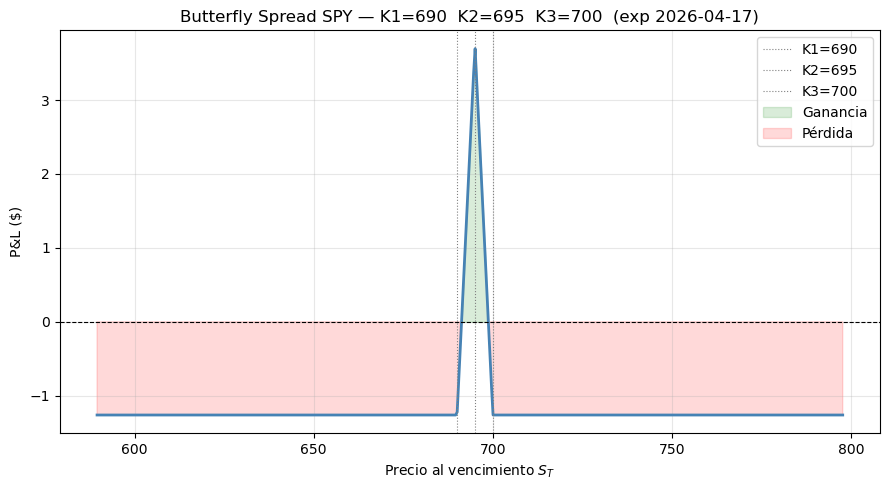

In [10]:
# ── Elige tres strikes ATM ± un paso (~10 puntos para SPY) ──────────────────
# Ajusta K1, K2, K3 a los strikes disponibles más cercanos a S0
import math

step = 5   # paso típico de strikes de SPY

K2 = round(S0 / step) * step           # strike central (ATM)
K1 = K2 - step                         # wing inferior
K3 = K2 + step                         # wing superior

C1 = get_call_mid(K1)
C2 = get_call_mid(K2)
C3 = get_call_mid(K3)

print(f"S0 = {S0:.2f}")
print(f"K1={K1}  prima call={C1:.2f}")
print(f"K2={K2}  prima call={C2:.2f}")
print(f"K3={K3}  prima call={C3:.2f}")

# P&L del butterfly: +1 call K1, -2 calls K2, +1 call K3
S_range = np.linspace(S0 * 0.85, S0 * 1.15, 500)

legs_butterfly = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': K3, 'prima': C3, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_butterfly)
prima_neta = C1 - 2*C2 + C3

print(f"\nPrima neta pagada : ${prima_neta:.2f}")
print(f"Ganancia máxima   : ${(K2-K1)-prima_neta:.2f}  (si ST = {K2})")
print(f"Pérdida máxima    : ${-prima_neta:.2f}")
print(f"Break-even inf.   : ${K1+prima_neta:.2f}  |  sup.: ${K3-prima_neta:.2f}")

graficar_estrategia(S_range, pnl,
                    f'Butterfly Spread SPY — K1={K1}  K2={K2}  K3={K3}  (exp {EXPIRY})',
                    K_lines=[(K1, f'K1={K1}'), (K2, f'K2={K2}'), (K3, f'K3={K3}')])

## 2. Iron Condor

S0 = 693.59
K_pl=685  put long  prima=1.69
K_ps=690  put short prima=2.83
K_cs=700  call short prima=0.92
K_cl=705  call long  prima=0.29

Prima cobrada     : $1.76  (ganancia máxima)
Pérdida máxima    : $3.24
Zona de ganancia  : [690, 700]


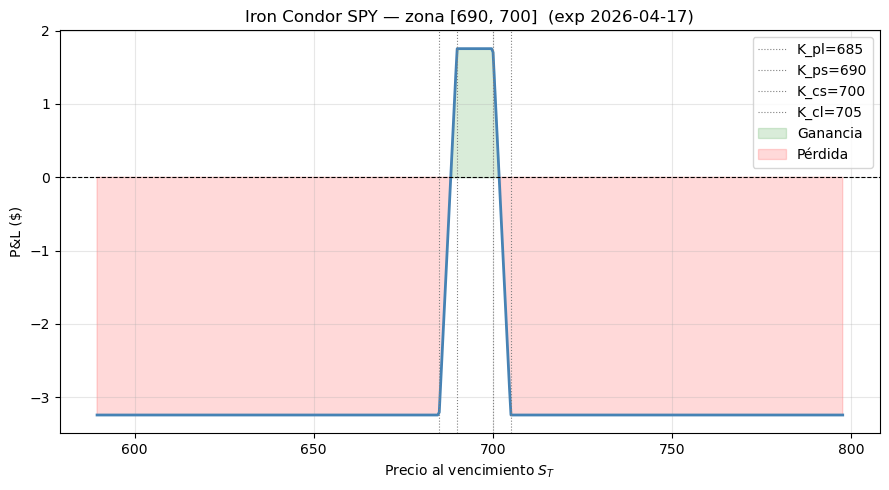

In [11]:
# ── Wings del condor ─────────────────────────────────────────────────────────
# Put spread: long K_pl  /  short K_ps  (por debajo de S0)
# Call spread: short K_cs  /  long K_cl (por encima de S0)
K_ps = K2 - step          # put short
K_pl = K_ps - step        # put long  (wing inferior)
K_cs = K2 + step          # call short
K_cl = K_cs + step        # call long  (wing superior)

P_l = get_put_mid(K_pl)
P_s = get_put_mid(K_ps)
C_s = get_call_mid(K_cs)
C_l = get_call_mid(K_cl)

print(f"S0 = {S0:.2f}")
print(f"K_pl={K_pl}  put long  prima={P_l:.2f}")
print(f"K_ps={K_ps}  put short prima={P_s:.2f}")
print(f"K_cs={K_cs}  call short prima={C_s:.2f}")
print(f"K_cl={K_cl}  call long  prima={C_l:.2f}")

legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_condor)
prima_cobrada = (P_s - P_l) + (C_s - C_l)
perdida_max   = (K_ps - K_pl) - prima_cobrada

print(f"\nPrima cobrada     : ${prima_cobrada:.2f}  (ganancia máxima)")
print(f"Pérdida máxima    : ${perdida_max:.2f}")
print(f"Zona de ganancia  : [{K_ps}, {K_cs}]")

graficar_estrategia(S_range, pnl,
                    f'Iron Condor SPY — zona [{K_ps}, {K_cs}]  (exp {EXPIRY})',
                    K_lines=[(K_pl, f'K_pl={K_pl}'), (K_ps, f'K_ps={K_ps}'),
                             (K_cs, f'K_cs={K_cs}'), (K_cl, f'K_cl={K_cl}')])

## 3. Covered Call

S0 = 693.59
K_cc=700  call prima=0.92


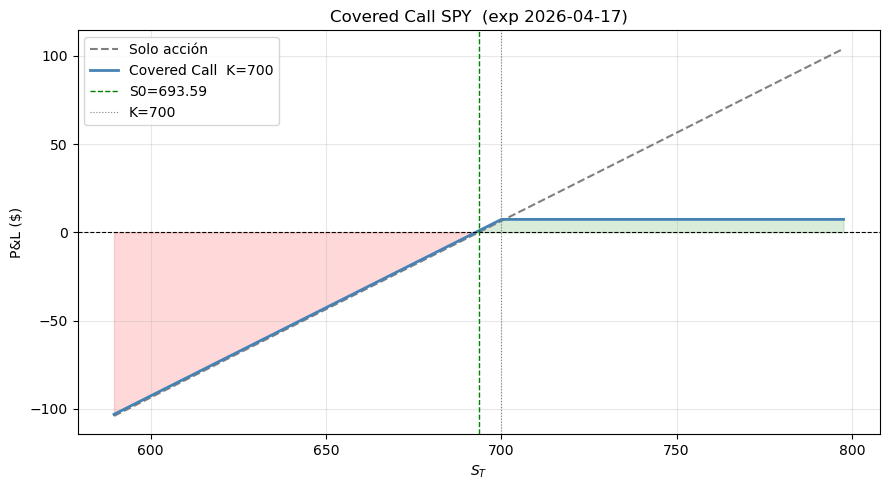

Ganancia máxima : $7.33  (si ST ≥ 700)
Break-even      : $692.67


In [12]:
# ── Call OTM ~5 puntos por encima de S0 ──────────────────────────────────────
K_cc = K2 + step          # call strike OTM
C_cc = get_call_mid(K_cc)

print(f"S0 = {S0:.2f}")
print(f"K_cc={K_cc}  call prima={C_cc:.2f}")

pnl_accion  = S_range - S0
pnl_covered = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)

plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,  color='gray',      linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_covered, color='steelblue', linewidth=2,
         label=f'Covered Call  K={K_cc}')
plt.axhline(0,    color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,   color='green', linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
plt.axvline(K_cc, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_cc}')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered > 0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered < 0), alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title(f'Covered Call SPY  (exp {EXPIRY})')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Ganancia máxima : ${K_cc - S0 + C_cc:.2f}  (si ST ≥ {K_cc})")
print(f"Break-even      : ${S0 - C_cc:.2f}")

## 4. Protective Put

S0 = 693.59
K_pp=690  put prima=2.83


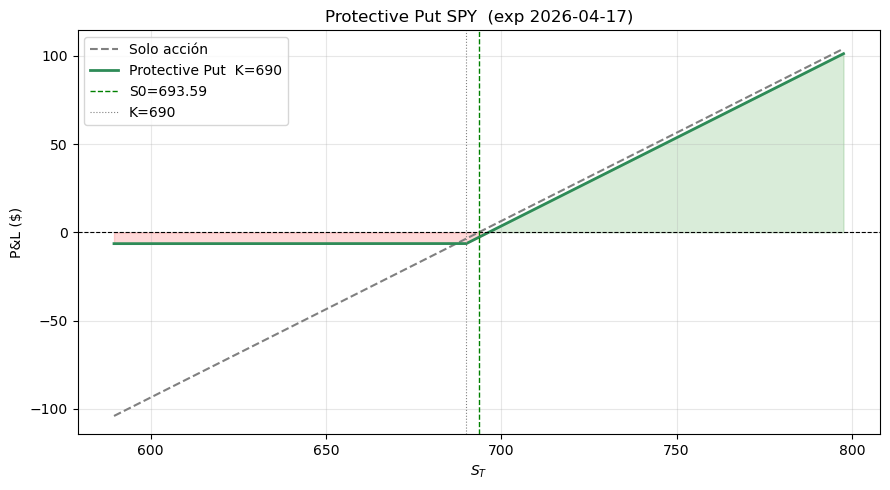

Pérdida máxima : $-6.41  (si ST ≤ 690)
Break-even     : $696.41


In [14]:
# ── Put OTM ~5 puntos por debajo de S0 ───────────────────────────────────────
K_pp = K2 - step          # put strike OTM
P_pp = get_put_mid(K_pp)

print(f"S0 = {S0:.2f}")
print(f"K_pp={K_pp}  put prima={P_pp:.2f}")

pnl_protective = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)

plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,     color='gray',    linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_protective, color='seagreen', linewidth=2,
         label=f'Protective Put  K={K_pp}')
plt.axhline(0,    color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,   color='green', linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
plt.axvline(K_pp, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_pp}')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective > 0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective < 0), alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title(f'Protective Put SPY  (exp {EXPIRY})')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Pérdida máxima : ${-(S0 - K_pp + P_pp):.2f}  (si ST ≤ {K_pp})")
print(f"Break-even     : ${S0 + P_pp:.2f}")

## 5. Tabla Resumen de las Cuatro Estrategias

In [15]:
import pandas as pd

resumen = {
    "Estrategia": [
        "Butterfly Spread",
        "Iron Condor",
        "Covered Call",
        "Protective Put",
    ],
    "Prima neta": [
        f"${prima_neta:.2f} (pagada)" if prima_neta > 0 else f"${abs(prima_neta):.2f} (cobrada)",
        f"${prima_cobrada:.2f} (cobrada)",
        f"${C_cc:.2f} (cobrada)",
        f"${P_pp:.2f} (pagada)",
    ],
    "Ganancia máxima": [
        f"${(K2-K1)-prima_neta:.2f}  (ST = {K2})",
        f"${prima_cobrada:.2f}  (ST ∈ [{K_ps}, {K_cs}])",
        f"${K_cc - S0 + C_cc:.2f}  (ST ≥ {K_cc})",
        "Ilimitada (por encima del break-even)",
    ],
    "Pérdida máxima": [
        f"${-prima_neta:.2f}",
        f"${perdida_max:.2f}",
        f"${-(S0 - C_cc):.2f}  (ST → 0)",
        f"${-(S0 - K_pp + P_pp):.2f}  (ST ≤ {K_pp})",
    ],
    "Break-even(s)": [
        f"{K1+prima_neta:.2f}  /  {K3-prima_neta:.2f}",
        f"{K_ps - prima_cobrada:.2f}  /  {K_cs + prima_cobrada:.2f}",
        f"{S0 - C_cc:.2f}",
        f"{S0 + P_pp:.2f}",
    ],
}

df_resumen = pd.DataFrame(resumen).set_index("Estrategia")
df_resumen

,Prima neta,Ganancia máxima,Pérdida máxima,Break-even(s)
Estrategia,,,,
Butterfly Spread,$1.26 (pagada),$3.74 (ST = 695),$-1.26,691.26 / 698.74
Iron Condor,$1.76 (cobrada),"$1.76 (ST ∈ [690, 700])",$3.24,688.25 / 701.75
Covered Call,$0.92 (cobrada),$7.33 (ST ≥ 700),$-692.67 (ST → 0),692.67
Protective Put,$2.83 (pagada),Ilimitada (por encima del break-even),$-6.41 (ST ≤ 690),696.41


- Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?

Iron Condor. La visión es que no ocurrirá nada extravagante con el precio pronto

- Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.

El peor excenario es que suba el precio muchísimo o que baje muchísimo

- Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.

Prefiero vender un iron condor. El iron condor tiene exposición a la Vega, entonces venderlo significa que mientras más pase el tiempo, más me beneficio ya que eventualmente se regresará a la media de la volatilidad. 

- El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.

Porque estaría generando el valor de la prima aunque no venda la acción. Aparte, la prima obtenida sirve como pequeño conchoncito ante pequeños bajones

- Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".

Es como un seguro porque pagas aunque estés ganando (Ganas menos siempre), pero cuando el precio cae feo se te asegura un precio menos peor. No es como un seguro porque puedes revenderlo cuando crees que ya no te conviene 

- ¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.

Son como lo mismo, excepto que el butterfly apuesta a que el activo cae en un precio específico. El Iron condor se va mejor por un rango de precios

- Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?

El valor de mi posición aumenta, ya que se vuelve más probable que sí se mantenga en el precio al que yo le aposté